In [ ]:
!pip install einops
!pip install timm
!pip install peft
!pip install roboflow git+https://github.com/roboflow/supervision.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
!pip install transformers==4.49.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 47.0 MB/s eta 0:00:00


In [ ]:
import io
import os
import re
import json
import torch
import html
import base64
import itertools

import numpy as np
import supervision as sv

from IPython.display import display, HTML
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # ✅ Updated import
from transformers import (
    AutoModelForCausalLM,
    AutoProcessor,
    get_scheduler
)
from tqdm import tqdm
from typing import List, Dict, Any, Tuple, Generator
from peft import LoraConfig, get_peft_model, PeftModel
from PIL import Image
from roboflow import Roboflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the model using `AutoModelForCausalLM` and the processor using `AutoProcessor` classes from the transformers library. Note that you need to pass `trust_remote_code` as `True` since this model is not a standard transformers model.

In [ ]:
# Constants
MODEL_PATH = "/content/drive/MyDrive/epoch_25"
# MODEL_PATH = r"C:\Users\cynth\Downloads\florence2-lora-retrained-20250406T063957Z-001\florence2-lora-retrained"   # Update with actual model path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Define paths
base_model_id = "microsoft/Florence-2-base-ft"  # Base model used for LoRA fine-tuning

# Enable trust_remote_code to avoid prompts
processor = AutoProcessor.from_pretrained(MODEL_PATH, trust_remote_code=True)

# Load the base model
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    revision="refs/pr/6"
).to(DEVICE)

# Load the fine-tuned LoRA model from the saved directory
peft_model = PeftModel.from_pretrained(base_model, MODEL_PATH).to(DEVICE)

# Optional: Print model device placement
print("PEFT Model loaded and placed on:", next(peft_model.parameters()).device)

Model with `tie_word_embeddings=True` and the tied_target_modules=['language_model.lm_head'] are part of the adapter. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. See for example https://github.com/huggingface/peft/issues/2018.


PEFT Model loaded and placed on: cuda:0


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Npr82rgYiQ5A5trJBlb8")
project = rf.workspace("capstone2025-mifho").project("military-base-object-detection")
version = project.version(15)
dataset = version.download("florence2-od")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
# @title Define `DetectionsDataset` class

class JSONLDataset:
    def __init__(self, jsonl_file_path: str, image_directory_path: str):
        self.jsonl_file_path = jsonl_file_path
        self.image_directory_path = image_directory_path
        self.entries = self._load_entries()

    def _load_entries(self) -> List[Dict[str, Any]]:
        entries = []
        with open(self.jsonl_file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                entries.append(data)
        return entries

    def __len__(self) -> int:
        return len(self.entries)

    def __getitem__(self, idx: int) -> Tuple[Image.Image, Dict[str, Any]]:
        if idx < 0 or idx >= len(self.entries):
            raise IndexError("Index out of range")

        entry = self.entries[idx]
        image_path = os.path.join(self.image_directory_path, entry['image'])
        try:
            image = Image.open(image_path)
            return (image, entry)
        except FileNotFoundError:
            raise FileNotFoundError(f"Image file {image_path} not found.")


class DetectionDataset(Dataset):
    def __init__(self, jsonl_file_path: str, image_directory_path: str):
        self.dataset = JSONLDataset(jsonl_file_path, image_directory_path)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, data = self.dataset[idx]
        prefix = data['prefix']
        suffix = data['suffix']
        return prefix, suffix, image

In [ ]:
# @title Initiate `DetectionsDataset` and `DataLoader` for train and validation subsets

BATCH_SIZE = 4
NUM_WORKERS = 0

def collate_fn(batch):
    questions, answers, images = zip(*batch)
    inputs = processor(text=list(questions), images=list(images), return_tensors="pt", padding=True).to(DEVICE)
    return inputs, answers

val_dataset = DetectionDataset(
    jsonl_file_path = f"{dataset.location}/valid/annotations.jsonl",
    image_directory_path = f"{dataset.location}/valid/"
)
test_dataset = DetectionDataset(
    jsonl_file_path = f"{dataset.location}/test/annotations.jsonl",
    image_directory_path = f"{dataset.location}/test/"
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=NUM_WORKERS)

In [ ]:
torch.cuda.empty_cache()

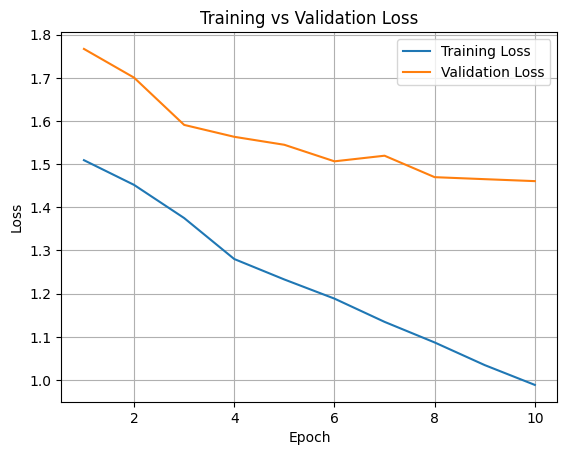

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
train_loss = [1.509146496, 1.451913585, 1.375092581, 1.280150507, 1.232772345,
              1.188435142, 1.1345855, 1.086884382, 1.034384113, 0.988501778]
val_loss = [1.766913983, 1.700414191, 1.590892504, 1.563305358, 1.544828533,
            1.506496092, 1.519515001, 1.469803361, 1.465170792, 1.460625875]

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## Fine-tuned model evaluation

**NOTE:** It seems that the model can still detect classes that don't belong to our custom dataset.

In [ ]:
# @title Collect predictions

PATTERN = r'([A-Za-z]+(-[A-Za-z]+)*)<loc_\d+>'

def extract_classes(dataset: DetectionDataset):
    class_set = set()
    for i in range(len(dataset.dataset)):
        image, data = dataset.dataset[i]
        suffix = data["suffix"]
        classes = re.findall(PATTERN, suffix)
        # print(classes)
        class_set.update(classes)
    return sorted(class_set)

CLASSES = extract_classes(test_dataset)



In [ ]:
print(CLASSES)

[('Aircraft', ''), ('Camouflage', ''), ('Drone', ''), ('Fire', ''), ('Grenade', ''), ('Hand-Gun', '-Gun'), ('Knife', ''), ('Military-Vehicle', '-Vehicle'), ('Missile', ''), ('Pistol', ''), ('Rifle', ''), ('Smoke', ''), ('Soldier', '')]


In [ ]:
CLASSES = [cls[0] for cls in CLASSES]

In [ ]:
print(CLASSES)

['Aircraft', 'Camouflage', 'Drone', 'Fire', 'Grenade', 'Hand-Gun', 'Knife', 'Military-Vehicle', 'Missile', 'Pistol', 'Rifle', 'Smoke', 'Soldier']


# Validation Dataset

In [ ]:
from tqdm import tqdm  # Progress bar

targets = []
predictions = []

# Iterate over the dataset with a progress bar
for i in tqdm(range(len(val_dataset.dataset)), desc="Evaluating Model", unit="image"):
    try:
        image, data = val_dataset.dataset[i]
        prefix = data['prefix']
        suffix = data['suffix']  # Ground truth annotation

        # Prepare input for the model
        inputs = processor(text=prefix, images=image, return_tensors="pt").to(DEVICE)
        generated_ids = peft_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=1024,
            num_beams=3
        )
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

        # Process model prediction
        prediction = processor.post_process_generation(generated_text, task='<OD>', image_size=image.size)
        prediction = sv.Detections.from_vlm("florence_2", prediction, resolution_wh=image.size)
        prediction = prediction[np.isin(prediction['class_name'], CLASSES)]

        prediction.class_id = np.array([CLASSES.index(class_name) for class_name in prediction['class_name']])
        prediction.confidence = np.ones(len(prediction))

        target = processor.post_process_generation(suffix, task='<OD>', image_size=image.size)
        target = sv.Detections.from_vlm("florence_2", target, resolution_wh=image.size)
        target.class_id = np.array([CLASSES.index(class_name) for class_name in target['class_name']])
        targets.append(target)
        predictions.append(prediction)

    except Exception as e:
        print(f"Error processing index {i}: {e}")

# Print summary
print(f"\nProcessed {len(targets)} samples successfully.")


Evaluating Model:  23%|██▎       | 449/1911 [03:31<09:45,  2.50image/s]

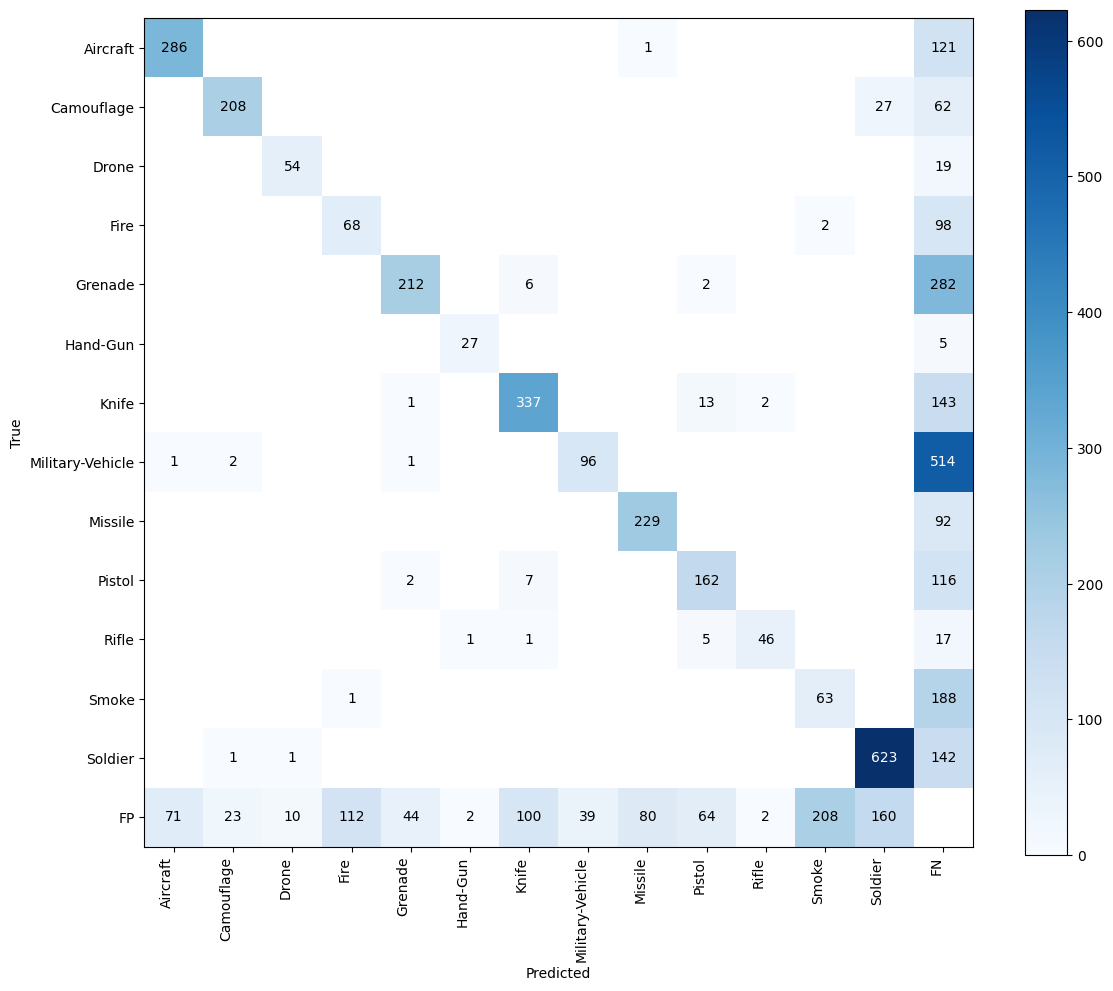

In [ ]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=CLASSES
)

_ = confusion_matrix.plot()

In [ ]:
def calculate_per_class_map50(predictions, targets, classes):
    per_class_map50 = {}

    for class_idx, class_name in enumerate(classes):
        class_preds = []
        class_targets = []

        for pred, tgt in zip(predictions, targets):
            pred_mask = pred.class_id == class_idx
            tgt_mask = tgt.class_id == class_idx

            class_preds.append(pred[pred_mask])
            class_targets.append(tgt[tgt_mask])

        # Compute mAP only at IoU 0.5
        class_map = sv.MeanAveragePrecision.from_detections(
            predictions=class_preds,
            targets=class_targets
        )

        per_class_map50[class_name] = class_map.map50

    return per_class_map50

per_class_map50 = calculate_per_class_map50(predictions, targets, CLASSES)

print("\n--- Per-Class mAP@50 ---")
for class_name, map50 in per_class_map50.items():
    print(f"Class: {class_name:15s} | mAP@50: {map50:.5f}")

MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_


--- Per-Class mAP@50 ---
Class: Aircraft        | mAP@50: 0.69019
Class: Camouflage      | mAP@50: 0.80689
Class: Drone           | mAP@50: 0.79614
Class: Fire            | mAP@50: 0.32362
Class: Grenade         | mAP@50: 0.63935
Class: Hand-Gun        | mAP@50: 0.89330
Class: Knife           | mAP@50: 0.70449
Class: Military-Vehicle | mAP@50: 0.43083
Class: Missile         | mAP@50: 0.64954
Class: Pistol          | mAP@50: 0.65810
Class: Rifle           | mAP@50: 0.81783
Class: Smoke           | mAP@50: 0.18969
Class: Soldier         | mAP@50: 0.76898


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [ ]:
# Calculate overall mAP@50
overall_map50 = sum(per_class_map50.values()) / len(per_class_map50)

print(f"\n✅ Overall mAP@50: {overall_map50:.5f}")



✅ Overall mAP@50: 0.64377


In [ ]:
def calculate_per_class_map75(predictions, targets, classes):
    per_class_map75 = {}

    for class_idx, class_name in enumerate(classes):
        class_preds = []
        class_targets = []

        for pred, tgt in zip(predictions, targets):
            pred_mask = pred.class_id == class_idx
            tgt_mask = tgt.class_id == class_idx

            class_preds.append(pred[pred_mask])
            class_targets.append(tgt[tgt_mask])

        # Compute mAP only at IoU 0.75
        class_map = sv.MeanAveragePrecision.from_detections(
            predictions=class_preds,
            targets=class_targets
        )

        per_class_map75[class_name] = class_map.map75

    return per_class_map75

per_class_map75 = calculate_per_class_map75(predictions, targets, CLASSES)

print("\n--- Per-Class mAP@75 ---")
for class_name, map75 in per_class_map75.items():
    print(f"Class: {class_name:15s} | mAP@75: {map75:.5f}")

MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_


--- Per-Class mAP@75 ---
Class: Aircraft        | mAP@75: 0.30515
Class: Camouflage      | mAP@75: 0.53477
Class: Drone           | mAP@75: 0.61642
Class: Fire            | mAP@75: 0.08875
Class: Grenade         | mAP@75: 0.56170
Class: Hand-Gun        | mAP@75: 0.75904
Class: Knife           | mAP@75: 0.60755
Class: Military-Vehicle | mAP@75: 0.22343
Class: Missile         | mAP@75: 0.50466
Class: Pistol          | mAP@75: 0.62724
Class: Rifle           | mAP@75: 0.73785
Class: Smoke           | mAP@75: 0.02901
Class: Soldier         | mAP@75: 0.56624


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [ ]:
# Calculate overall mAP@50
overall_map75 = sum(per_class_map75.values()) / len(per_class_map75)

print(f"\n✅ Overall mAP@75: {overall_map75:.5f}")



✅ Overall mAP@75: 0.47398


In [ ]:
def calculate_per_class_map50_95(predictions, targets, classes):
    per_class_map50_95 = {}

    for class_idx, class_name in enumerate(classes):
        class_preds = []
        class_targets = []

        for pred, tgt in zip(predictions, targets):
            pred_mask = pred.class_id == class_idx
            tgt_mask = tgt.class_id == class_idx

            class_preds.append(pred[pred_mask])
            class_targets.append(tgt[tgt_mask])

        # Compute mAP only at IoU 0.5
        class_map = sv.MeanAveragePrecision.from_detections(
            predictions=class_preds,
            targets=class_targets
        )

        per_class_map50_95[class_name] = class_map.map50_95

    return per_class_map50_95

per_class_map50_95 = calculate_per_class_map50_95(predictions, targets, CLASSES)

print("\n--- Per-Class mAP@50_95 ---")
for class_name, map50_95 in per_class_map50_95.items():
    print(f"Class: {class_name:15s} | mAP@50_95: {map50_95:.5f}")

MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_


--- Per-Class mAP@50_95 ---
Class: Aircraft        | mAP@50_95: 0.34635
Class: Camouflage      | mAP@50_95: 0.50638
Class: Drone           | mAP@50_95: 0.56722
Class: Fire            | mAP@50_95: 0.13355
Class: Grenade         | mAP@50_95: 0.52387
Class: Hand-Gun        | mAP@50_95: 0.75720
Class: Knife           | mAP@50_95: 0.55867
Class: Military-Vehicle | mAP@50_95: 0.24243
Class: Missile         | mAP@50_95: 0.45539
Class: Pistol          | mAP@50_95: 0.58081
Class: Rifle           | mAP@50_95: 0.68593
Class: Smoke           | mAP@50_95: 0.06580
Class: Soldier         | mAP@50_95: 0.54697


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [ ]:
# Calculate overall mAP@50
overall_map50_95 = sum(per_class_map50_95.values()) / len(per_class_map50_95)

print(f"\n✅ Overall mAP@50_95: {overall_map50_95:.5f}")


✅ Overall mAP@50_95: 0.45927


In [ ]:
import numpy as np
import pandas as pd

# Function to calculate per-class accuracy
def per_class_accuracy(targets, predictions, class_names):
    class_wise_results = {}

    for class_id, class_name in enumerate(class_names):
        # Get all ground truth instances of the class
        total_targets = sum(class_id in t.class_id for t in targets)

        # Get all correctly predicted instances of the class
        correct_predictions = sum(
            class_id in t.class_id and class_id in p.class_id
            for t, p in zip(targets, predictions)
        )

        # Calculate accuracy
        accuracy = (correct_predictions / total_targets) if total_targets > 0 else 0.0
        class_wise_results[class_name] = round(accuracy * 100, 2)  # Convert to percentage

    return class_wise_results

# Generate accuracy table
accuracy_results = per_class_accuracy(targets, predictions, CLASSES)

# Convert to DataFrame for better readability
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=["Class", "Accuracy (%)"])

# Calculate average accuracy
average_accuracy = accuracy_df["Accuracy (%)"].mean()

# Display accuracy table and average accuracy
print(accuracy_df)
print(f"\nAverage Accuracy: {average_accuracy:.2f}%")


               Class  Accuracy (%)
0           Aircraft         98.43
1         Camouflage         96.55
2              Drone         80.82
3               Fire         86.59
4            Grenade         85.92
5           Hand-Gun         96.67
6              Knife         84.66
7   Military-Vehicle        100.00
8            Missile         98.28
9             Pistol         92.96
10             Rifle         70.18
11             Smoke         96.69
12           Soldier         96.13

Average Accuracy: 91.07%


# Test dataset


In [ ]:
from tqdm import tqdm  # Progress bar

targets1 = []
predictions1 = []

# Iterate over the dataset with a progress bar
for i in tqdm(range(len(test_dataset.dataset)), desc="Evaluating Model", unit="image"):
    try:
        image, data = test_dataset.dataset[i]
        prefix = data['prefix']
        suffix = data['suffix']  # Ground truth annotation

        # Prepare input for the model
        inputs = processor(text=prefix, images=image, return_tensors="pt").to(DEVICE)
        generated_ids = peft_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=1024,
            num_beams=3
        )
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

        # Process model prediction
        prediction = processor.post_process_generation(generated_text, task='<OD>', image_size=image.size)
        prediction = sv.Detections.from_vlm("florence_2", prediction, resolution_wh=image.size)
        prediction = prediction[np.isin(prediction['class_name'], CLASSES)]

        prediction.class_id = np.array([CLASSES.index(class_name) for class_name in prediction['class_name']])
        prediction.confidence = np.ones(len(prediction))

        target = processor.post_process_generation(suffix, task='<OD>', image_size=image.size)
        target = sv.Detections.from_vlm("florence_2", target, resolution_wh=image.size)
        target.class_id = np.array([CLASSES.index(class_name) for class_name in target['class_name']])
        targets1.append(target)
        predictions1.append(prediction)

    except Exception as e:
        print(f"Error processing index {i}: {e}")

# Print summary
print(f"\nProcessed {len(targets1)} samples successfully.")


Evaluating Model: 100%|██████████| 1767/1767 [13:39<00:00,  2.16image/s]


Processed 1767 samples successfully.


In [ ]:
per_class_map50_test = calculate_per_class_map50(predictions1, targets1, CLASSES)

print("\n--- Per-Class mAP@50 ---")
for class_name, map50 in per_class_map50_test.items():
    print(f"Class: {class_name:15s} | mAP@50: {map50:.5f}")

MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_


--- Per-Class mAP@50 ---
Class: Aircraft        | mAP@50: 0.77504
Class: Camouflage      | mAP@50: 0.79447
Class: Drone           | mAP@50: 0.72798
Class: Fire            | mAP@50: 0.38918
Class: Grenade         | mAP@50: 0.67378
Class: Hand-Gun        | mAP@50: 0.87121
Class: Knife           | mAP@50: 0.61345
Class: Military-Vehicle | mAP@50: 0.46578
Class: Missile         | mAP@50: 0.68849
Class: Pistol          | mAP@50: 0.72490
Class: Rifle           | mAP@50: 0.81296
Class: Smoke           | mAP@50: 0.16928
Class: Soldier         | mAP@50: 0.71425


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [ ]:
# Calculate overall mAP@50
overall_map50_test = sum(per_class_map50_test.values()) / len(per_class_map50_test)

print(f"\n✅ Overall mAP@50: {overall_map50_test:.5f}")



✅ Overall mAP@50: 0.64775


In [ ]:
per_class_map75_test = calculate_per_class_map75(predictions1, targets1, CLASSES)

print("\n--- Per-Class mAP@75 ---")
for class_name, map75 in per_class_map75_test.items():
    print(f"Class: {class_name:15s} | mAP@75: {map75:.5f}")

MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_


--- Per-Class mAP@75 ---
Class: Aircraft        | mAP@75: 0.41860
Class: Camouflage      | mAP@75: 0.54830
Class: Drone           | mAP@75: 0.41844
Class: Fire            | mAP@75: 0.09475
Class: Grenade         | mAP@75: 0.60993
Class: Hand-Gun        | mAP@75: 0.75595
Class: Knife           | mAP@75: 0.47158
Class: Military-Vehicle | mAP@75: 0.32994
Class: Missile         | mAP@75: 0.50228
Class: Pistol          | mAP@75: 0.60464
Class: Rifle           | mAP@75: 0.74936
Class: Smoke           | mAP@75: 0.03801
Class: Soldier         | mAP@75: 0.50434


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [ ]:
# Calculate overall mAP@75
overall_map75_test = sum(per_class_map75_test.values()) / len(per_class_map75_test)

print(f"\n✅ Overall mAP@75: {overall_map75_test:.5f}")



✅ Overall mAP@75: 0.46509


In [ ]:
per_class_map50_95_test = calculate_per_class_map50_95(predictions1, targets1, CLASSES)

print("\n--- Per-Class mAP@50_95 ---")
for class_name, map50_95 in per_class_map50_95_test.items():
    print(f"Class: {class_name:15s} | mAP@50_95: {map50_95:.5f}")

MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.
MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_


--- Per-Class mAP@50_95 ---
Class: Aircraft        | mAP@50_95: 0.43107
Class: Camouflage      | mAP@50_95: 0.51191
Class: Drone           | mAP@50_95: 0.42476
Class: Fire            | mAP@50_95: 0.15461
Class: Grenade         | mAP@50_95: 0.54994
Class: Hand-Gun        | mAP@50_95: 0.68291
Class: Knife           | mAP@50_95: 0.47372
Class: Military-Vehicle | mAP@50_95: 0.31714
Class: Missile         | mAP@50_95: 0.48612
Class: Pistol          | mAP@50_95: 0.57856
Class: Rifle           | mAP@50_95: 0.70115
Class: Smoke           | mAP@50_95: 0.05723
Class: Soldier         | mAP@50_95: 0.49293


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [ ]:
# Calculate overall mAP@50_95
overall_map50_95_test = sum(per_class_map50_95_test.values()) / len(per_class_map50_95_test)

print(f"\n✅ Overall mAP@50_95: {overall_map50_95_test:.5f}")


✅ Overall mAP@50_95: 0.45093


In [ ]:
import numpy as np
import pandas as pd

# Function to calculate per-class accuracy
def per_class_accuracy(targets, predictions, class_names):
    class_wise_results = {}

    for class_id, class_name in enumerate(class_names):
        # Get all ground truth instances of the class
        total_targets = sum(class_id in t.class_id for t in targets)

        # Get all correctly predicted instances of the class
        correct_predictions = sum(
            class_id in t.class_id and class_id in p.class_id
            for t, p in zip(targets, predictions)
        )

        # Calculate accuracy
        accuracy = (correct_predictions / total_targets) if total_targets > 0 else 0.0
        class_wise_results[class_name] = round(accuracy * 100, 2)  # Convert to percentage

    return class_wise_results

# Generate accuracy table
accuracy_results = per_class_accuracy(targets1, predictions1, CLASSES)

# Convert to DataFrame for better readability
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=["Class", "Accuracy (%)"])

# Calculate average accuracy
average_accuracy = accuracy_df["Accuracy (%)"].mean()

# Display accuracy table and average accuracy
print(accuracy_df)
print(f"\nAverage Accuracy: {average_accuracy:.2f}%")


               Class  Accuracy (%)
0           Aircraft         99.21
1         Camouflage         95.22
2              Drone         82.86
3               Fire         80.00
4            Grenade         82.43
5           Hand-Gun         93.33
6              Knife         75.61
7   Military-Vehicle         87.22
8            Missile         97.84
9             Pistol         93.90
10             Rifle         72.41
11             Smoke         87.70
12           Soldier         96.36

Average Accuracy: 88.01%
